In [2]:
!pip install pnmf

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PNMF import PNMF

In [4]:
import torch
from torch import optim
from torch import distributions
import torch.nn as nn

In [5]:
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split
from torchvision.datasets import KMNIST

In [6]:
# Load KMNIST dataset from torch
kmnist = KMNIST(root='./data', train=True, download=True)
x_train = kmnist.data.numpy().astype(np.float32) / 255.0  # Normalize to [0, 1]
y_train = kmnist.targets.numpy()

print(f"Dataset shape: {x_train.shape}")  # (N, 28, 28)

100%|██████████| 18.2M/18.2M [00:11<00:00, 1.52MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 281kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 2.18MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 10.2MB/s]


Dataset shape: (60000, 28, 28)


In [7]:
mask = y_train ==2

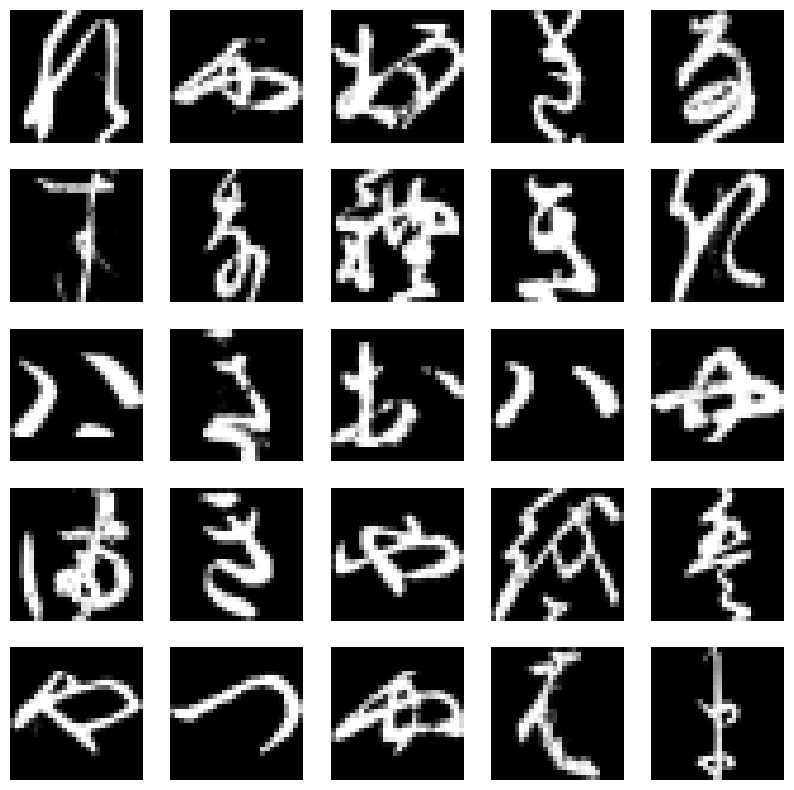

In [8]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
X = x_train.reshape(-1, 28*28)

In [11]:
L = 49  # latent dimensions (7x7 grid for visualization)

In [31]:
# Use PNMF from the library
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_np = (X * 255).astype(np.float32)  # Scale to count-like values

model = PNMF(
    n_components=L,
    random_state=42,
    verbose=True,
    max_iter=1000,
    tol=1e-4,
    learning_rate=5e-2,
    device=device
)

W = model.fit_transform(X_np)

Iteration 0: ELBO = 4040207616.000000
Iteration 10: ELBO = 6753219072.000000
Iteration 20: ELBO = 7057525760.000000
Iteration 30: ELBO = 7143661056.000000
Iteration 40: ELBO = 7187168256.000000
Iteration 50: ELBO = 7255260672.000000
Iteration 60: ELBO = 7389097984.000000
Iteration 70: ELBO = 7545842176.000000
Iteration 80: ELBO = 7673503232.000000
Iteration 90: ELBO = 7787033088.000000
Iteration 100: ELBO = 7888355328.000000
Iteration 110: ELBO = 7974455808.000000
Iteration 120: ELBO = 8047675904.000000
Iteration 130: ELBO = 8110543872.000000
Iteration 140: ELBO = 8163596800.000000
Iteration 150: ELBO = 8210973184.000000
Iteration 160: ELBO = 8250739712.000000
Iteration 170: ELBO = 8286897664.000000
Iteration 180: ELBO = 8318700032.000000
Iteration 190: ELBO = 8349255168.000000
Iteration 200: ELBO = 8375241728.000000
Iteration 210: ELBO = 8398974976.000000
Iteration 220: ELBO = 8422498304.000000
Iteration 230: ELBO = 8441424384.000000
Iteration 240: ELBO = 8462572544.000000
Iteration 2

In [32]:
# No optimizer needed - PNMF handles it internally

In [33]:
# Model is already trained! Check the results:
print(f"ELBO: {model.elbo_:.4f}")
print(f"Iterations: {model.n_iter_}")
print(f"Components (W) shape: {model.components_.shape}")
print(f"Transformed (H) shape: {W.shape}")

ELBO: 8797131776.0000
Iterations: 889
Components (W) shape: (49, 784)
Transformed (H) shape: (60000, 49)


In [34]:
# Plot ELBO convergence if available
# (The sklearn API doesn't store full history, but we can see the final value)
print(f"Final ELBO: {model.elbo_:.4f}")

Final ELBO: 8797131776.0000


In [67]:
# Extract the learned components and transformed data
log_factors = model._model.prior.mean.T.detach().cpu()
factors = torch.exp(log_factors).detach()
loadings = torch.tensor(model.components_)

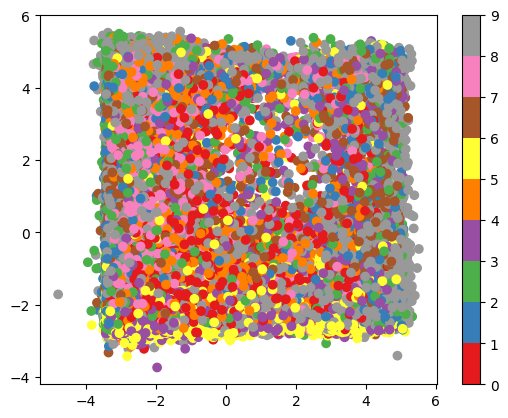

In [68]:
plt.scatter(log_factors[:,0], log_factors[:,4], c=y_train, cmap='Set1') #work on this
plt.colorbar()

In [69]:
# Reconstruction using the learned W and H
reconstruction = factors @ loadings

In [70]:
reconstruction.shape

torch.Size([60000, 784])

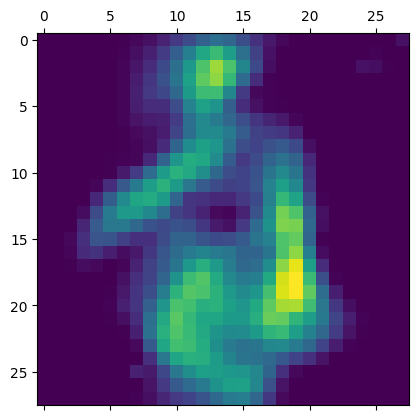

In [71]:
plt.matshow(reconstruction[4].reshape(28,28))

In [72]:
# Check the learned factor values for a sample
print("Factor values for sample 2:")
print(factors[2])

Factor values for sample 2:
tensor([3.1716e-01, 4.4234e+01, 5.7981e-02, 1.0242e+01, 2.7188e+01, 9.8064e-02,
        8.3696e-02, 8.9098e-01, 7.3119e+01, 1.4778e+02, 2.2534e-01, 5.0849e-01,
        3.5969e+01, 6.3353e-02, 4.0479e+00, 1.9151e+01, 9.4578e+00, 1.4242e+01,
        1.4052e+02, 4.0811e+00, 7.8320e-02, 4.9333e-01, 4.0443e-01, 2.8536e+01,
        2.0867e-01, 3.5816e+01, 5.3998e+01, 8.5983e-02, 6.6673e+00, 2.2523e-01,
        7.1128e-02, 1.9632e-01, 4.0270e+01, 5.8471e-02, 2.6155e-01, 1.1343e+02,
        2.0991e-01, 1.1816e+02, 5.0011e-02, 9.5382e+01, 6.0010e-01, 5.9311e-01,
        2.9508e+01, 2.5728e-01, 7.2601e-01, 7.8334e+00, 3.2422e-01, 7.5124e+00,
        1.3675e-01])


In [73]:
print(f"Max component value: {loadings.max():.4f}")

Max component value: 7.6446


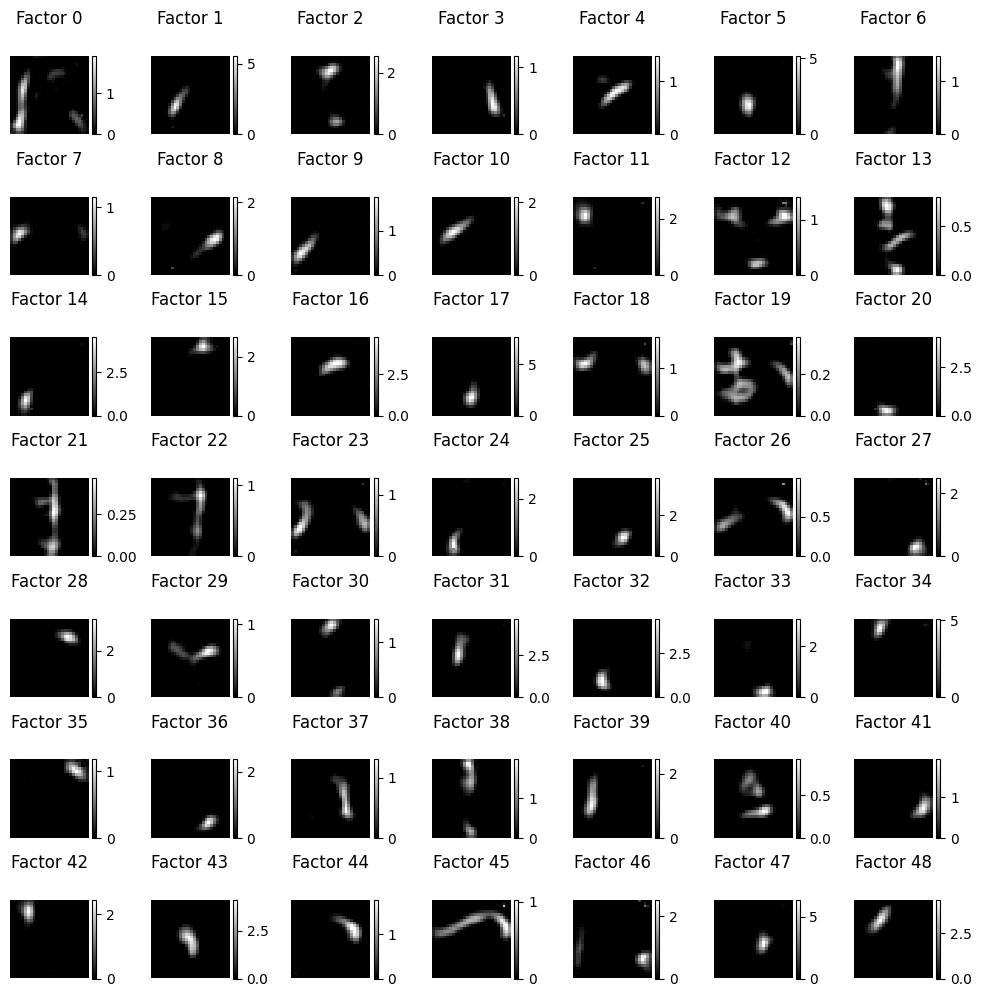

In [74]:
# Visualize all learned basis components
fig = plt.figure(figsize=(10, 10))
for l in range(L):
    ax = plt.subplot(7, 7, l + 1)
    im = ax.matshow(loadings[l].reshape(28, 28), cmap='gray', vmin=0, )
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.title(f'Factor {l}')

plt.tight_layout()
plt.show()

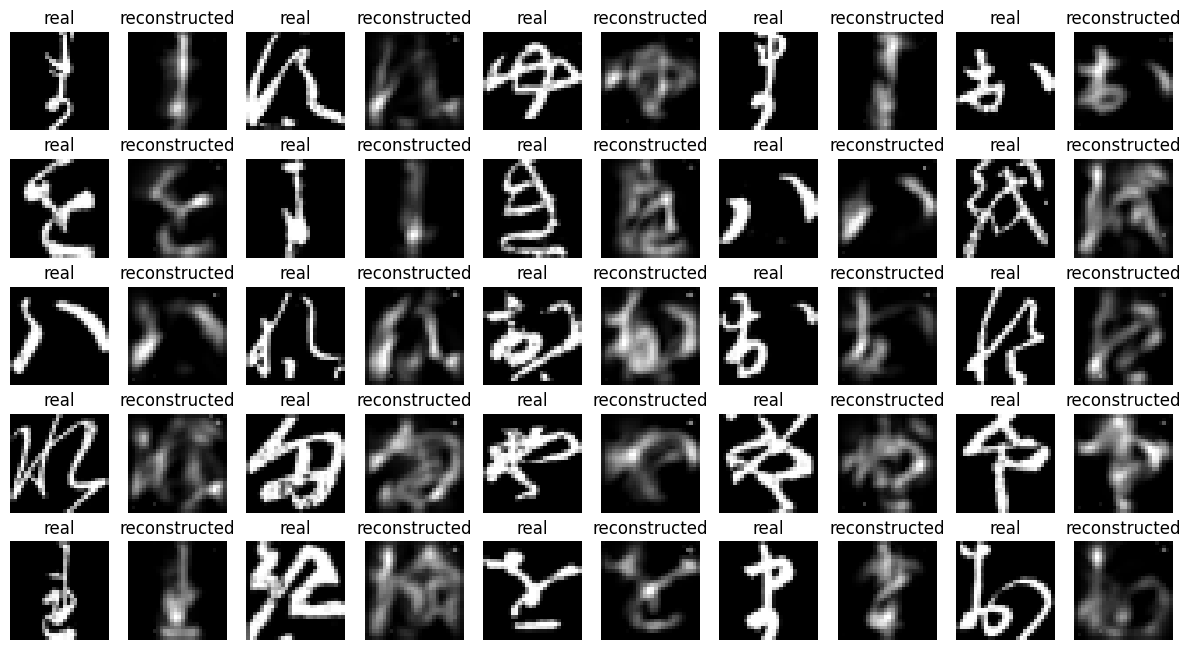

In [75]:
plt.figure(figsize=(15, 8))
for i in range(25):
    plt.subplot(5,10,(2*i)+1)
    plt.title('real')
    plt.imshow(x_train[i+25].reshape(28, 28), cmap='gray')
    plt.axis('off')

    plt.subplot(5,10,(2*i)+2)
    plt.title('reconstructed')
    plt.imshow(reconstruction[i+25].reshape(28, 28), cmap='gray')
    plt.axis('off')

/tmp/ipython-input-196849974.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  order = torch.tensor(factors[k]).argsort(descending=True)[:10]


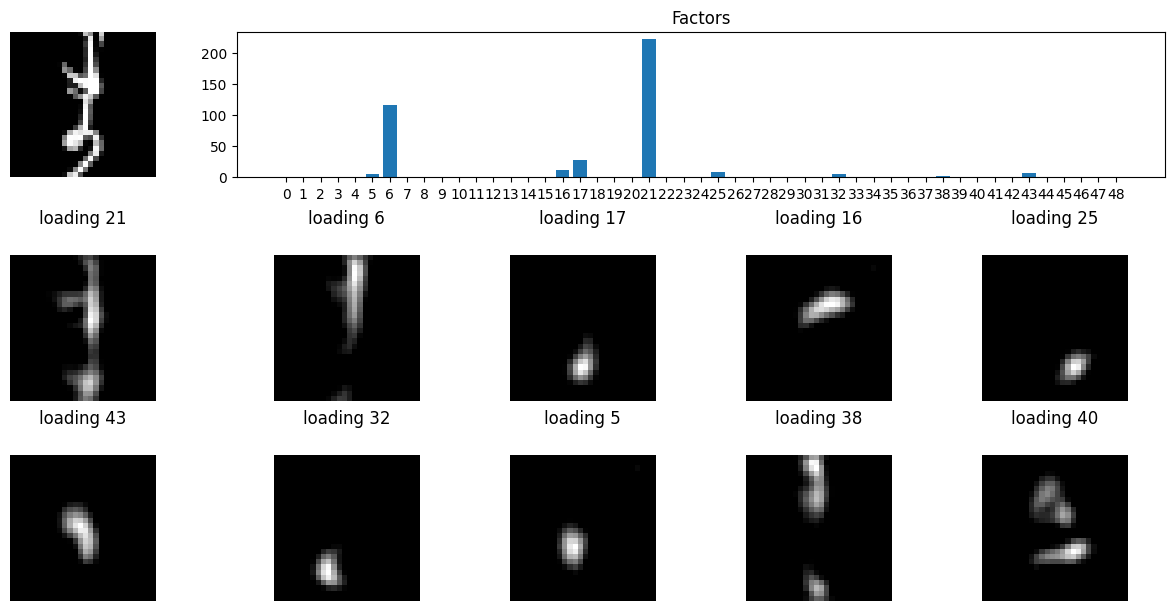

In [76]:
# Analyze a specific sample and its top factors
k = 25
x = np.arange(0, L)

fig = plt.figure(figsize=(12, 6), layout="constrained")
spec = fig.add_gridspec(3, 5)

ax0 = fig.add_subplot(spec[0, 0])
ax0.matshow(x_train[k].reshape(28, 28), cmap='gray')
ax0.axis('off')

ax1 = fig.add_subplot(spec[0, 1:])
plt.title('Factors')
ax1.bar(x, factors[k])
ax1.set_xticks(x);

order = torch.tensor(factors[k]).argsort(descending=True)[:10]

for l in range(10):
    current_ax = fig.add_subplot(spec[1+l//5, l%5])
    loading_current = loadings[order]
    im = current_ax.matshow(loading_current[l].reshape(28, 28), cmap='gray', vmin=0)
    current_ax.set_axis_off()
    plt.title(f'loading {order[l]}')

plt.show()